Airbnb NYC Analysis” is a data analysis project that explores Airbnb listings in New York City to understand price trends, room types, neighborhood patterns, and availability. The project involves cleaning the dataset, performing exploratory data analysis, visualizing listings on maps, and identifying insights for travelers and hosts. Optional predictive modeling is included to estimate listing prices based on location, room type, and availability. The project helps travelers find affordable stays and hosts optimize their pricing strategies.

In [31]:
import pandas as pd
df=pd.read_csv("airnb.csv")
df.head()


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [33]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [34]:
df.drop_duplicates(inplace=True)
df['price'] = df['price'].replace('[\$,]', '', regex=True).astype(float)
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)


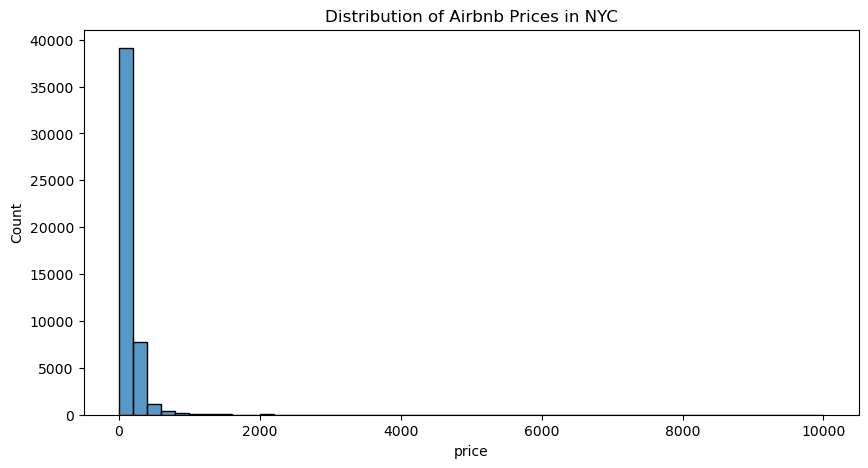

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,5))
sns.histplot(df['price'],bins=50)
plt.title("Distribution of Airbnb Prices in NYC")
plt.show()

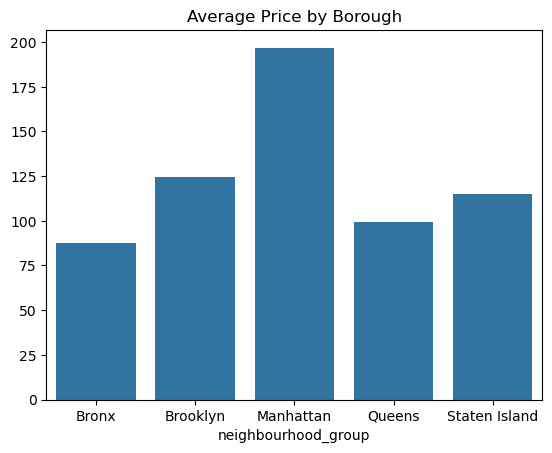

In [36]:
avg_price=df.groupby('neighbourhood_group')['price'].mean()
sns.barplot(x=avg_price.index, y=avg_price.values)
plt.title("Average Price by Borough")
plt.show()


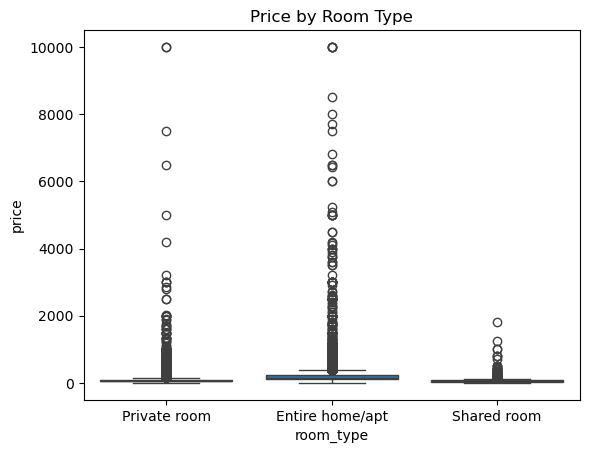

In [37]:
sns.boxplot(x='room_type', y='price', data=df)
plt.title("Price by Room Type")
plt.show()

In [38]:
!pip install folium

In [39]:
import folium
nyc_map = folium.Map(location=[40.7128, -74.0060], zoom_start=11)
for idx, row in df.head(100).iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=3,
        color='blue' if row['price'] < 200 else 'red',
        fill=True
    ).add_to(nyc_map)

nyc_map

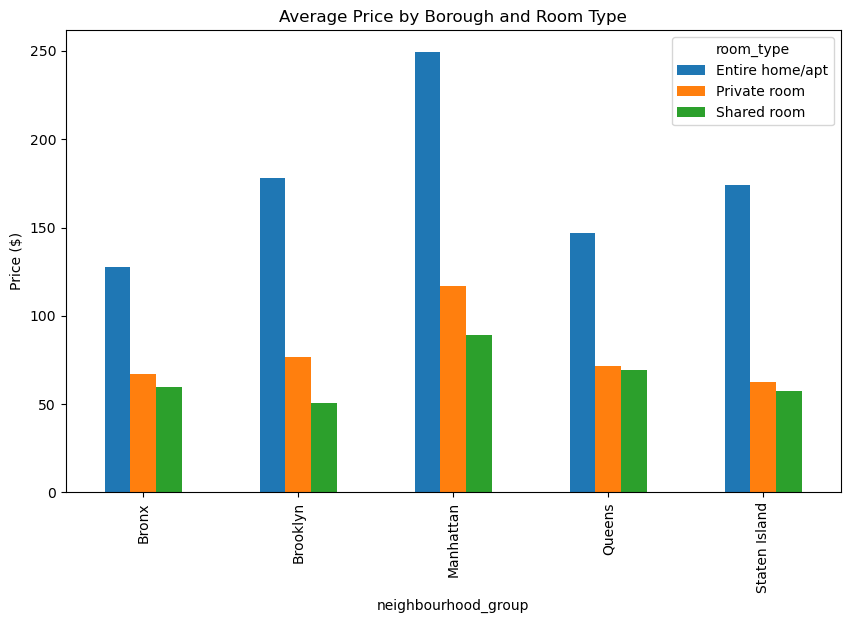

In [40]:
price_trends = df.groupby(['neighbourhood_group', 'room_type'])['price'].mean().unstack()
price_trends.plot(kind='bar', figsize=(10,6))
plt.title("Average Price by Borough and Room Type")
plt.ylabel("Price ($)")
plt.show()

                                                  name  availability_365  \
48868                     Heaven for you(only for guy)               365   
5933        Penthouse Flat, Million-$-View, Best Area!               365   
40941       Specious 4-people room in nice surrounding               365   
40981               Vibrant Private Bedroom in UWS 107               365   
48844  West Village Studio on quiet cobblestone street               365   
15687              CENTRAL PARK / COLUMBUS CIRCLE /1BR               365   
15659                 Spacious 3 Bedroom in Park Slope               365   
40933                                    Chic and cozy               365   
40908                                Crown heights apt               365   
5972    Sleeps 6 by Metro/Subway - 15 mns to Manhattan               365   

       price  
48868   25.0  
5933   200.0  
40941   31.0  
40981   60.0  
48844  205.0  
15687   87.0  
15659  135.0  
40933   95.0  
40908  130.0  
5972   180.0 

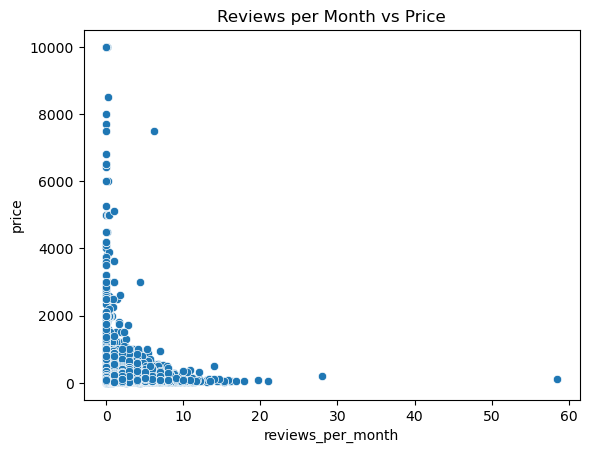

In [41]:
top_available = df[['name','availability_365','price']].sort_values(by='availability_365', ascending=False).head(10)
print(top_available)

sns.scatterplot(x='reviews_per_month', y='price', data=df)
plt.title("Reviews per Month vs Price")
plt.show()

In [42]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = pd.get_dummies(df[['neighbourhood_group','room_type','minimum_nights']], drop_first=True)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [43]:
print("Train R^2:", model.score(X_train, y_train))
print("Test R^2:", model.score(X_test, y_test))

Train R^2: 0.07766312914989215
Test R^2: 0.10451818866836571


In [44]:
avg_price_borough = df.groupby('neighbourhood_group')['price'].mean().sort_values(ascending=False)
print("Average price by borough:")
print(avg_price_borough)


Average price by borough:
neighbourhood_group
Manhattan        196.875814
Brooklyn         124.383207
Staten Island    114.812332
Queens            99.517649
Bronx             87.496792
Name: price, dtype: float64


C:\Users\Neha\AppData\Local\Temp\ipykernel_23544\2082225763.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_price_borough.index, y=avg_price_borough.values, palette='coolwarm')


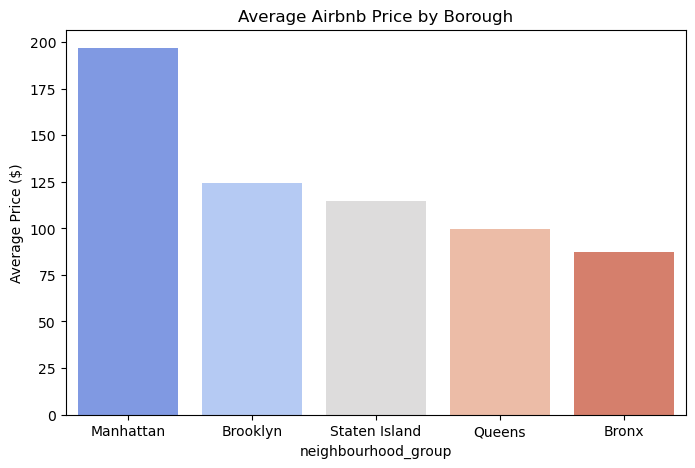

In [45]:
plt.figure(figsize=(8,5))
sns.barplot(x=avg_price_borough.index, y=avg_price_borough.values, palette='coolwarm')
plt.title("Average Airbnb Price by Borough")
plt.ylabel("Average Price ($)")
plt.show()

In [46]:
avg_price_room = df.groupby('room_type')['price'].mean().sort_values(ascending=False)
print("\nAverage price by room type:")
print(avg_price_room)


Average price by room type:
room_type
Entire home/apt    211.794246
Private room        89.780973
Shared room         70.127586
Name: price, dtype: float64


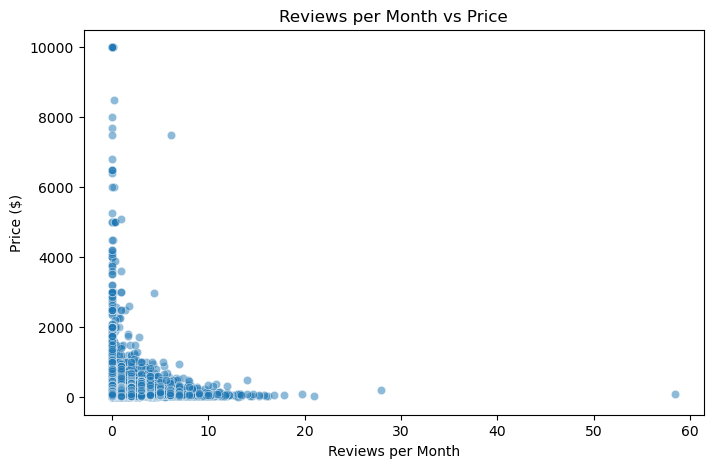

In [47]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='reviews_per_month', y='price', data=df, alpha=0.5)
plt.title("Reviews per Month vs Price")
plt.xlabel("Reviews per Month")
plt.ylabel("Price ($)")
plt.show()

In [48]:
correlation = df['reviews_per_month'].corr(df['price'])
print(f"\nCorrelation between reviews per month and price: {correlation:.2f}")




Correlation between reviews per month and price: -0.05


In [49]:
top_availability = df[['name','neighbourhood_group','availability_365','price']].sort_values(by='availability_365', ascending=False).head(10)
print("\nTop 10 listings with highest availability:")
print(top_availability)




Top 10 listings with highest availability:
                                                  name neighbourhood_group  \
48868                     Heaven for you(only for guy)            Brooklyn   
5933        Penthouse Flat, Million-$-View, Best Area!            Brooklyn   
40941       Specious 4-people room in nice surrounding            Brooklyn   
40981               Vibrant Private Bedroom in UWS 107           Manhattan   
48844  West Village Studio on quiet cobblestone street           Manhattan   
15687              CENTRAL PARK / COLUMBUS CIRCLE /1BR           Manhattan   
15659                 Spacious 3 Bedroom in Park Slope            Brooklyn   
40933                                    Chic and cozy           Manhattan   
40908                                Crown heights apt            Brooklyn   
5972    Sleeps 6 by Metro/Subway - 15 mns to Manhattan            Brooklyn   

       availability_365  price  
48868               365   25.0  
5933                365  200.0 

In [50]:
print("\nInsights & Recommendations:")
print("- Most expensive borough:", avg_price_borough.idxmax())
print("- Cheapest borough:", avg_price_borough.idxmin())
print("- Entire home/apartment is generally pricier than private/shared rooms.")
print("- Listings with more reviews tend to have higher price.")
print("- High availability listings are more suitable for long-term stays.")
print("- Hosts can optimize pricing by comparing with similar listings in the same neighborhood.")


Insights & Recommendations:
- Most expensive borough: Manhattan
- Cheapest borough: Bronx
- Entire home/apartment is generally pricier than private/shared rooms.
- Listings with more reviews tend to have higher price.
- High availability listings are more suitable for long-term stays.
- Hosts can optimize pricing by comparing with similar listings in the same neighborhood.
